In [1]:
# Installs
!pip install requests
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install tqdm

In [2]:
# Imports/Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [3]:
# Loading TMDB API Key
import os
from dotenv import load_dotenv

load_dotenv()
TMDB_API_KEY = os.getenv("TMDB_API_KEY")
print(TMDB_API_KEY)

None


In [4]:
# First API Test (If [200], API Call was successful)
url = f"https://api.themoviedb.org/3/discover/movie?api_key=56d74cf46936c9b4d1c664fb170584eb&page=1"
response = requests.get(url)
response

<Response [200]>

In [5]:
#Look @ JSON
response.json()["results"][:5]

[{'adult': False,
  'backdrop_path': '/qeQJx07rK2xm8SD2sJxFKhE7gs0.jpg',
  'genre_ids': [878, 28, 12],
  'id': 969681,
  'title': 'Spider-Man: Brand New Day',
  'original_language': 'en',
  'original_title': 'Spider-Man: Brand New Day',
  'overview': "Fighting crime full-time as Spider-Man in a world that doesn't remember him—and the pressure of seeing his old friends move on without him—sparks a change in Peter Parker he may not have the power to control. But that transformation might also be the only thing that can stop a shocking new threat to the city and those he loves - a powerful villain no one can even see.",
  'popularity': 756.7679,
  'poster_path': '/bjiS5ipwxb9JFy3XRRN4OAilSeX.jpg',
  'release_date': '2026-07-29',
  'softcore': False,
  'video': False,
  'vote_average': 7.844,
  'vote_count': 2646},
 {'adult': False,
  'backdrop_path': '/l9mFW9HQnAZ4r1ChZJHoOT3jaal.jpg',
  'genre_ids': [35, 12, 10751],
  'id': 1204680,
  'title': 'Coyote vs. Acme',
  'original_language': 'e

In [6]:
# 1. Get Genre Mapping Dictionary
genre_url = f"https://api.themoviedb.org/3/genre/movie/list?api_key=56d74cf46936c9b4d1c664fb170584eb"
genres_data = requests.get(genre_url).json().get('genres', [])
genre_map = {g['id']: g['name'] for g in genres_data}

movies_data = []

In [7]:
# 2. Get movies from Discover API (Limiting to 10 pgs for a solid sample size)
print("Getting movie list...")
for page in tqdm(range(1, 11)):
    discover_url = f"https://api.themoviedb.org/3/discover/movie?api_key=56d74cf46936c9b4d1c664fb170584eb&page=2"
    results = requests.get(discover_url).json().get('results', [])

for movie in results:
        # Extract primary genre (first ID in the list)
        primary_genre_id = movie['genre_ids'][0] if movie.get('genre_ids') else None

        movies_data.append({
                    'movie_id': movie['id'],
                    'title': movie['title'],
                    'primary_genre': genre_map.get(primary_genre_id, "Unknown"),
                    'vote_average': movie['vote_average'],
                    'vote_count': movie['vote_count'],
                    'popularity': movie['popularity']
            })
df_movies = pd.DataFrame(movies_data)

Getting movie list...


100%|██████████| 10/10 [00:00<00:00, 18.63it/s]


In [8]:
# 3. Get Runtime from Movie Details API
print("Fetching runtimes...")
runtimes = []
for movie_id in tqdm(df_movies['movie_id']):
    details_url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key=56d74cf46936c9b4d1c664fb170584eb"
    details = requests.get(details_url).json()
    runtimes.append(details.get('runtime', pd.NA))

df_movies['runtime'] = runtimes

Fetching runtimes...


100%|██████████| 20/20 [00:01<00:00, 15.14it/s]


In [9]:
# Data Cleaning Steps using Pandas
print(f"Original Dataset Size: {df_movies.shape}")

# 1. Drop rows with missing runtimes or ratings
df_clean = df_movies.dropna(subset=['runtime', 'vote_average'])

# 2. Filter out movies with low vote counts to avoid skewed rating averages
df_clean = df_clean[df_clean['vote_count'] >= 100]

# 3. Filter out movies with 0 runtime (data errors)
df_clean = df_clean[df_clean['runtime'] > 0]

print(f"Cleaned Dataset Size: {df_clean.shape}")
display(df_clean.head())

Original Dataset Size: (20, 7)
Cleaned Dataset Size: (11, 7)


,movie_id,title,primary_genre,vote_average,vote_count,popularity,runtime
0,1560520,Batman: Knightfall Part 1: Knightfall,Animation,9.174,290,114.7291,79
5,1101383,The End of Oak Street,Science Fiction,6.351,483,101.6103,100
9,860508,The Whisper Man,Crime,6.803,644,92.0494,111
10,1275779,Disclosure Day,Science Fiction,7.469,3295,91.3835,146
11,980431,Avatar Aang: The Last Airbender,Animation,9.149,1114,91.1521,99


/var/folders/sr/mcgs4cjn3rvc0bxlj632h5n80000gn/T/ipykernel_5412/1985723567.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="viridis")


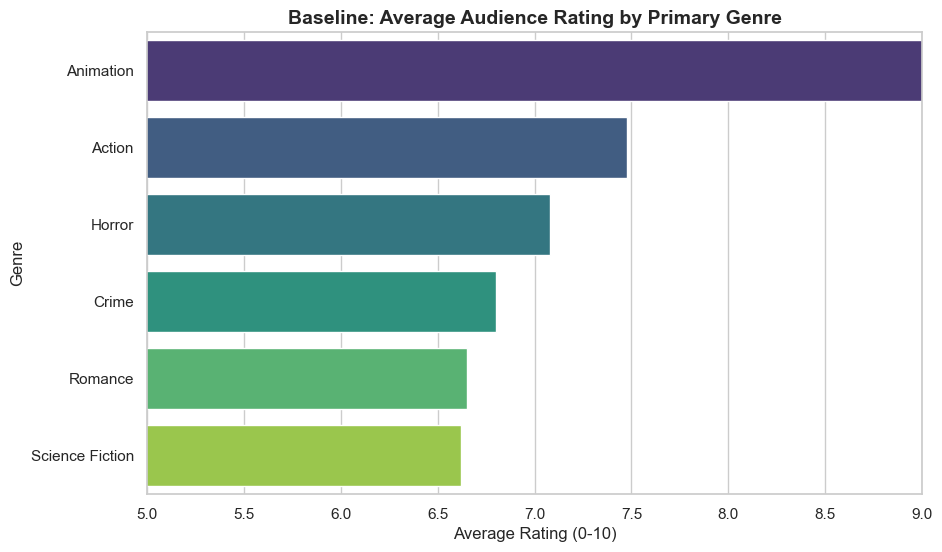

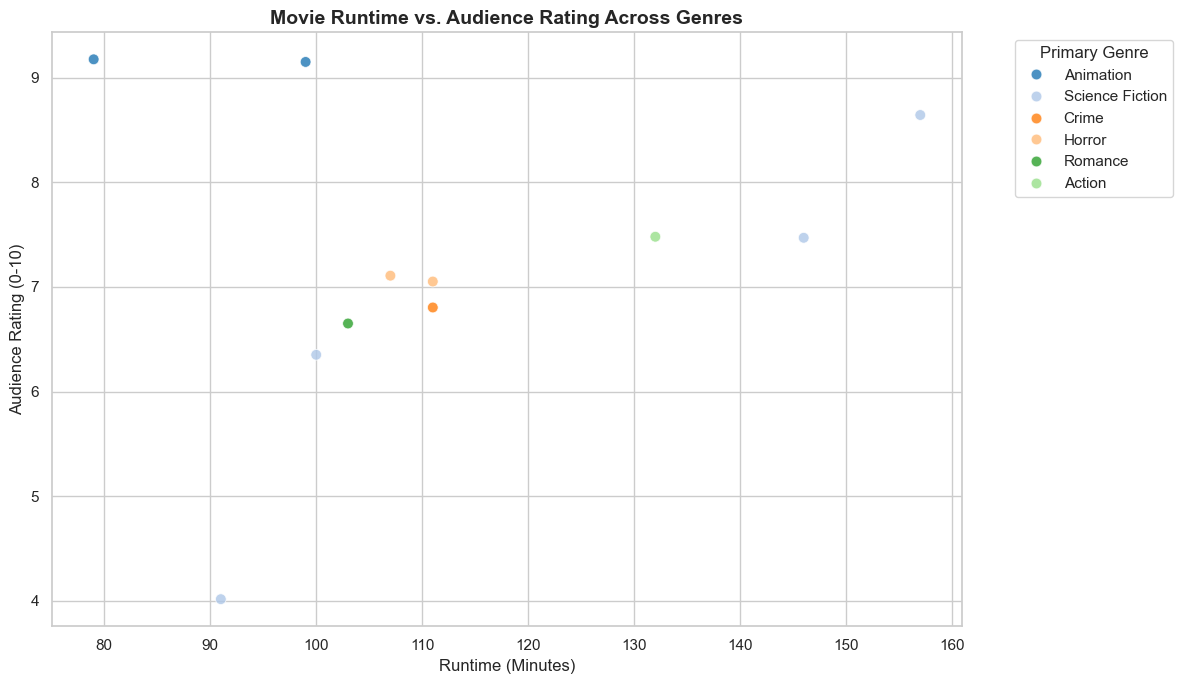

In [10]:
# Set visualization style
sns.set_theme(style="whitegrid")

# Figure 1: Horizontal Bar Chart - Establishing the Genre Baseline
plt.figure(figsize=(10, 6))
genre_ratings = df_clean.groupby('primary_genre')['vote_average'].mean().sort_values(ascending=False)
sns.barplot(x=genre_ratings.values, y=genre_ratings.index, palette="viridis")
plt.title("Baseline: Average Audience Rating by Primary Genre", fontsize=14, fontweight='bold')
plt.xlabel("Average Rating (0-10)", fontsize=12)
plt.ylabel("Genre", fontsize=12)
plt.xlim(5, 9) 
plt.show()

# Figure 2: Scatter Plot - Runtime vs Rating colored by Genre[cite: 1, 2]
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df_clean, x='runtime', y='vote_average', hue='primary_genre', palette="tab20", s=60, alpha=0.8)
plt.title("Movie Runtime vs. Audience Rating Across Genres", fontsize=14, fontweight='bold')
plt.xlabel("Runtime (Minutes)", fontsize=12)
plt.ylabel("Audience Rating (0-10)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Primary Genre")
plt.tight_layout()
plt.show()